# 01 - EDA y contrato de datos

Exploración reproducible del CSV crudo. Este notebook no ajusta modelos ni modifica el *lockbox*.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists())
sys.path.insert(0, str(ROOT))
from src.data_prep.prepare_data import load_raw, dataset_profile

raw = load_raw(ROOT / 'data/raw/water_potability.csv')
profile = dataset_profile(raw)
profile

{'rows': 3276,
 'features': 9,
 'class_counts': {'0': 1998, '1': 1278},
 'missing_counts': {'ph': 491,
  'Hardness': 0,
  'Solids': 0,
  'Chloramines': 0,
  'Sulfate': 781,
  'Conductivity': 0,
  'Organic_carbon': 0,
  'Trihalomethanes': 162,
  'Turbidity': 0},
 'duplicate_rows': 0}

In [2]:
summary = pd.DataFrame({
    'dtype': raw.dtypes.astype(str),
    'missing': raw.isna().sum(),
    'missing_pct': (100 * raw.isna().mean()).round(2),
    'unique': raw.nunique(dropna=True),
})
display(summary)
display(raw['Potability'].value_counts().rename('count').to_frame().assign(percent=lambda d: 100*d['count']/len(raw)).round(2))

,dtype,missing,missing_pct,unique
sample_id,int64,0,0.00,3276
ph,float64,491,14.99,2785
Hardness,float64,0,0.00,3276
Solids,float64,0,0.00,3276
Chloramines,float64,0,0.00,3276
Sulfate,float64,781,23.84,2495
Conductivity,float64,0,0.00,3276
Organic_carbon,float64,0,0.00,3276
Trihalomethanes,float64,162,4.95,3114
Turbidity,float64,0,0.00,3276


,count,percent
Potability,,
0,1998,60.99
1,1278,39.01


,no_potable,potable
sample_id,0.00,0.00
ph,15.72,13.85
Hardness,0.00,0.00
Solids,0.00,0.00
Chloramines,0.00,0.00
Sulfate,24.42,22.93
Conductivity,0.00,0.00
Organic_carbon,0.00,0.00
Trihalomethanes,5.36,4.30
Turbidity,0.00,0.00


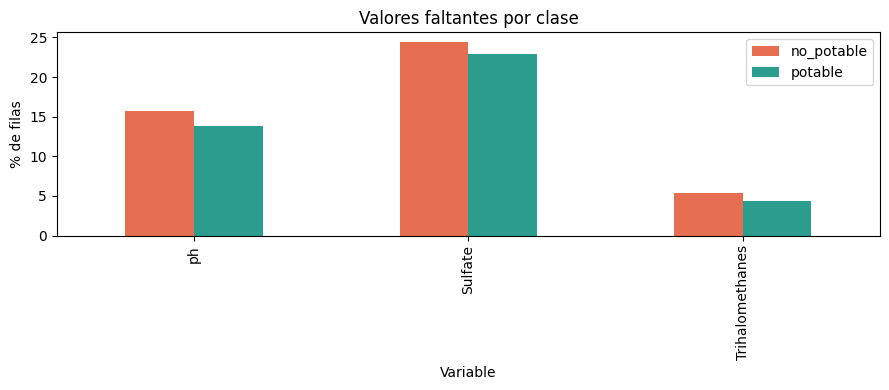

In [3]:
missing_by_class = raw.groupby('Potability').apply(lambda g: g.isna().mean(), include_groups=False).T
missing_by_class.columns = ['no_potable', 'potable']
display((100 * missing_by_class).round(2))

ax = (100 * missing_by_class.loc[missing_by_class.max(axis=1) > 0]).plot.bar(figsize=(9, 4), color=['#e76f51', '#2a9d8f'])
ax.set(title='Valores faltantes por clase', ylabel='% de filas', xlabel='Variable')
plt.tight_layout()

Conclusión: hay 3,276 observaciones, nueve predictores, desbalance 61/39 y faltantes concentrados en `ph`, `Sulfate` y `Trihalomethanes`. La imputación principal se ajusta dentro de cada fold y nunca usa la etiqueta de test.